# Customer Loyalty Program Analysis

## Setup & Data Preparation

In [73]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import datetime as dt
from lifelines import KaplanMeierFitter
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

df = pd.read_csv('../data/Business_Analytics_Dataset_10000_Rows.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df = df.sort_values(["Customer_ID", "Order_Date"])

## RFM Analysis
### Recency, Frequency, Monetary metrics

In [58]:
snapshot_date = df["Order_Date"].max() + dt.timedelta(days=1)

rfm = df.groupby("Customer_ID").agg({
    "Order_Date": lambda x: (snapshot_date - x.max()).days,
    "Order_ID": "count",
    "Revenue": "sum"
})
rfm.columns = ["Recency", "Frequency", "Monetary"]

print("\n=== RFM METRICS ===")
print(rfm.describe())


=== RFM METRICS ===
           Recency    Frequency      Monetary
count  5994.000000  5994.000000   5994.000000
mean    151.347347     1.668335   1994.063977
std     102.446764     0.881295   1641.610885
min       1.000000     1.000000     12.140000
25%      62.000000     1.000000    718.150000
50%     137.000000     1.000000   1611.710000
75%     232.000000     2.000000   2835.912500
max     366.000000     9.000000  15776.750000


In [94]:
snapshot_date = df["Order_Date"].max() + dt.timedelta(days=1)

rfm = df.groupby("Customer_ID").agg({
    "Order_Date": lambda x: (snapshot_date - x.max()).days,
    "Order_ID": "count",
    "Revenue": "sum"
})
rfm.columns = ["Recency", "Frequency", "Monetary"]

customer_segments = df[['Customer_ID', 'Customer_Segment']].drop_duplicates()
rfm = rfm.merge(customer_segments, on='Customer_ID', how='left')

rfm['R_pct'] = rfm.groupby('Customer_Segment')['Recency'].rank(pct=True)
rfm['F_pct'] = rfm.groupby('Customer_Segment')['Frequency'].rank(pct=True)
rfm['M_pct'] = rfm.groupby('Customer_Segment')['Monetary'].rank(pct=True)

conditions = [
    (rfm['F_pct'] > 0.7) & (rfm['M_pct'] > 0.7) & (rfm['R_pct'] > 0.6),  # Champions
    (rfm['F_pct'] > 0.6) & (rfm['M_pct'] > 0.6),                          # Loyal
    (rfm['M_pct'] > 0.7) & (rfm['F_pct'] < 0.4),                          # High spend, low frequency
    (rfm['F_pct'] > 0.7) & (rfm['M_pct'] < 0.4),                          # High frequency, low spend
    (rfm['R_pct'] < 0.3) & (rfm['F_pct'] < 0.3),                          # New
    (rfm['R_pct'] < 0.2),                                                  # Sleeping (churn risk)
]

group_names = [
    'Champions', 'Loyal', 'High_Spenders', 
    'Frequent_Buyers', 'New', 'At_Risk'
]

rfm['Group'] = np.select(conditions, group_names, default='Average')

print("\n=== LOYALTY PROGRAM BY SEGMENT & GROUP ===\n")

for segment in rfm['Customer_Segment'].unique():
    print(f"\n{'-'*50}")
    print(f"SEGMENT: {segment.upper()}")
    print(f"{'-'*50}")
    
    seg_data = rfm[rfm['Customer_Segment'] == segment]
    
    for group in seg_data['Group'].value_counts().index:
        count = len(seg_data[seg_data['Group'] == group])
        pct = count / len(seg_data) * 100
        avg_spend = seg_data[seg_data['Group'] == group]['Monetary'].mean()
        
        print(f"\n  {group} ({count} customers, {pct:.1f}%, avg ${avg_spend:.0f})")
        
        if segment == 'Corporate':
            if group == 'Champions':
                print("    → Volume discounts, dedicated account manager, quarterly business reviews")
            elif group == 'Loyal':
                print("    → Tiered pricing, priority support, consolidated billing")
            elif group == 'High_Spenders':
                print("    → Procurement incentives, bulk order discounts")
            elif group == 'Frequent_Buyers':
                print("    → Free expedited shipping, auto-replenishment options")
            elif group == 'New':
                print("    → Onboarding support, first-order volume discount")
            elif group == 'At_Risk':
                print("    → Account review, special retention offer, usage analysis")
            else:
                print("    → Standard corporate pricing, quarterly newsletter")
        
        elif segment == 'Consumer':
            if group == 'Champions':
                print("    → VIP perks, early access to sales, birthday gifts")
            elif group == 'Loyal':
                print("    → Points program (2x points), exclusive member prices")
            elif group == 'High_Spenders':
                print("    → Cashback offers, category-specific coupons")
            elif group == 'Frequent_Buyers':
                print("    → Free shipping, buy X get 1 free")
            elif group == 'New':
                print("    → Welcome discount (15% off next purchase)")
            elif group == 'At_Risk':
                print("    → Win-back coupon (20% off), 'We miss you' email")
            else:
                print("    → Standard promotions, email newsletter")
        
        else:  # Home Office
            if group == 'Champions':
                print("    → Hybrid rewards (personal + business), quarterly bonuses")
            elif group == 'Loyal':
                print("    → Office supplies focus, expense tracking tools")
            elif group == 'High_Spenders':
                print("    → Equipment upgrade discounts, extended warranty")
            elif group == 'Frequent_Buyers':
                print("    → Subscription model for consumables")
            elif group == 'New':
                print("    → Starter kit discount, setup assistance")
            elif group == 'At_Risk':
                print("    → Business needs assessment, personalized offer")
            else:
                print("    → Standard business pricing, monthly deals")

# Summary table - FIXED version with equal length lists
print("\n" + "="*60)
print("SUMMARY: PRIORITY BY SEGMENT")
print("="*60)

priority_data = {
    'Segment': ['Corporate', 'Consumer', 'Home Office', 
                'Corporate', 'Consumer', 'Home Office',
                'Corporate', 'Consumer', 'Home Office'],
    'Priority': ['High', 'High', 'High',
                 'Medium', 'Medium', 'Medium',
                 'Low', 'Low', 'Low'],
    'Focus': [
        'Champions & Loyal (retention)', 'New & Champions (growth)', 'Loyal & Champions (reward)',
        'High Spenders (convert)', 'Loyal & Frequent (upsell)', 'High Spenders (engage)',
        'At Risk (win-back)', 'Average (nurture)', 'At Risk (assess)'
    ]
}

priority = pd.DataFrame(priority_data)
print(priority.to_string(index=False))


=== LOYALTY PROGRAM BY SEGMENT & GROUP ===


--------------------------------------------------
SEGMENT: CORPORATE
--------------------------------------------------

  Average (1711 customers, 61.6%, avg $1724)
    → Standard corporate pricing, quarterly newsletter

  Loyal (451 customers, 16.2%, avg $4702)
    → Tiered pricing, priority support, consolidated billing

  At_Risk (257 customers, 9.3%, avg $2306)
    → Account review, special retention offer, usage analysis

  New (159 customers, 5.7%, avg $1037)
    → Onboarding support, first-order volume discount

  High_Spenders (74 customers, 2.7%, avg $3470)
    → Procurement incentives, bulk order discounts

  Champions (69 customers, 2.5%, avg $4888)
    → Volume discounts, dedicated account manager, quarterly business reviews

  Frequent_Buyers (57 customers, 2.1%, avg $1089)
    → Free expedited shipping, auto-replenishment options

--------------------------------------------------
SEGMENT: HOME OFFICE
-----------------------

##### Using RFM analysis, we can identify customers who score well across all three dimensions as valuable. Through this lens, we can establish valuable customer tiers, or identify customers who may have low Recency but actually have high Monetary or Frequency values.

##### The only limitation here is that we wouldn't know their response to a loyalty program. If we had data from a previous loyalty program, we could perform uplift analysis to identify customers who would respond positively to such a campaign - those who would become loyal specifically when we apply the treatment.

## Customer Lifetime Value (CLV) Estimation

In [91]:
date_range = df['Order_Date'].agg(['min', 'max'])
total_days = (date_range['max'] - date_range['min']).days
split_date = date_range['min'] + pd.Timedelta(days=int(total_days * 0.75))  # 75% for training

train_df = df[df['Order_Date'] <= split_date].copy()
test_df = df[df['Order_Date'] > split_date].copy()

customer_features = train_df.groupby('Customer_ID').agg({
    'Revenue': ['sum', 'mean'],
    'Order_ID': 'count',
    'Order_Date': ['min', 'max'],
    'Discount_Rate': 'mean',
    'Product_Category': 'nunique',
    'Payment_Method': 'nunique'
}).round(2)

customer_features.columns = ['total_revenue', 'avg_revenue', 'order_count',
                             'first_date', 'last_date', 'avg_discount', 
                             'category_diversity', 'payment_diversity']
customer_features = customer_features.reset_index()

customer_features['recency'] = (split_date - customer_features['last_date']).dt.days
customer_features['tenure'] = (customer_features['last_date'] - customer_features['first_date']).dt.days
customer_features['tenure'] = customer_features['tenure'].apply(lambda x: max(x, 1))
customer_features['avg_order_value'] = customer_features['total_revenue'] / customer_features['order_count']
customer_features['frequency_monthly'] = customer_features['order_count'] / (customer_features['tenure'] / 30)

future_revenue = test_df.groupby('Customer_ID')['Revenue'].sum().reset_index()
future_revenue.columns = ['Customer_ID', 'future_revenue']

clv_df = customer_features.merge(future_revenue, on='Customer_ID', how='left')
clv_df['future_revenue'] = clv_df['future_revenue'].fillna(0)

feature_cols = ['total_revenue', 'avg_revenue', 'order_count', 'recency', 'tenure',
                'avg_discount', 'category_diversity', 'payment_diversity', 
                'avg_order_value', 'frequency_monthly']
X = clv_df[feature_cols]
y = clv_df['future_revenue']

y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

dummy_mean = DummyRegressor(strategy='mean')
dummy_mean.fit(X_train, y_train)
y_pred_dummy = dummy_mean.predict(X_test)

print("=== BASELINE 1: MEAN PREDICTOR ===")
print(f"R²: {r2_score(y_test, y_pred_dummy):.3f}")
print(f"MAE (log): {mean_absolute_error(y_test, y_pred_dummy):.3f}")

y_test_actual = np.expm1(y_test)
y_pred_dummy_actual = np.expm1(y_pred_dummy)
print(f"MAE (actual $): ${mean_absolute_error(y_test_actual, y_pred_dummy_actual):.2f}")

X_train_hist = X_train[['total_revenue']]
X_test_hist = X_test[['total_revenue']]

lr_hist = LinearRegression()
lr_hist.fit(X_train_hist, y_train)
y_pred_hist = lr_hist.predict(X_test_hist)

print("=== BASELINE 2: HISTORICAL REVENUE ONLY ===")
print(f"R²: {r2_score(y_test, y_pred_hist):.3f}")
print(f"MAE (log): {mean_absolute_error(y_test, y_pred_hist):.3f}")

y_pred_hist_actual = np.expm1(y_pred_hist)
print(f"MAE (actual $): ${mean_absolute_error(y_test_actual, y_pred_hist_actual):.2f}")

X_train_rfm = X_train.copy()
X_train_rfm['rfm_score'] = (
    X_train_rfm['recency'].rank(pct=True) * 0.3 +
    X_train_rfm['order_count'].rank(pct=True) * 0.3 +
    X_train_rfm['total_revenue'].rank(pct=True) * 0.4
)

X_test_rfm = X_test.copy()
X_test_rfm['rfm_score'] = (
    X_test_rfm['recency'].rank(pct=True) * 0.3 +
    X_test_rfm['order_count'].rank(pct=True) * 0.3 +
    X_test_rfm['total_revenue'].rank(pct=True) * 0.4
)

lr_rfm = LinearRegression()
lr_rfm.fit(X_train_rfm[['rfm_score']], y_train)
y_pred_rfm = lr_rfm.predict(X_test_rfm[['rfm_score']])

print("=== BASELINE 3: RFM SCORE ONLY ===")
print(f"R²: {r2_score(y_test, y_pred_rfm):.3f}")
print(f"MAE (log): {mean_absolute_error(y_test, y_pred_rfm):.3f}")

y_pred_rfm_actual = np.expm1(y_pred_rfm)
print(f"MAE (actual $): ${mean_absolute_error(y_test_actual, y_pred_rfm_actual):.2f}")

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBOOST MODEL ===")
print(f"R²: {r2_score(y_test, y_pred_xgb):.3f}")
print(f"MAE (log): {mean_absolute_error(y_test, y_pred_xgb):.3f}")

y_pred_xgb_actual = np.expm1(y_pred_xgb)
print(f"MAE (actual $): ${mean_absolute_error(y_test_actual, y_pred_xgb_actual):.2f}")

baselines = {
    'Mean Predictor': mean_absolute_error(y_test_actual, y_pred_dummy_actual),
    'Historical Revenue Only': mean_absolute_error(y_test_actual, y_pred_hist_actual),
    'RFM Score': mean_absolute_error(y_test_actual, y_pred_rfm_actual),
    'XGBoost': mean_absolute_error(y_test_actual, y_pred_xgb_actual)
}

all_customers = X.copy()
all_customers['predicted_future_log'] = xgb_model.predict(all_customers)
all_customers['predicted_future'] = np.expm1(all_customers['predicted_future_log'])
all_customers['Customer_ID'] = clv_df['Customer_ID']
all_customers['total_historical'] = clv_df['total_revenue']
all_customers['predicted_clv'] = all_customers['total_historical'] + all_customers['predicted_future']

# Add segment
segments = df[['Customer_ID', 'Customer_Segment']].drop_duplicates()
all_customers = all_customers.merge(segments, on='Customer_ID', how='left')

print("\n=== PREDICTED CLV BY SEGMENT ===")
segment_clv = all_customers.groupby('Customer_Segment').agg({
    'predicted_clv': ['mean', 'sum'],
    'Customer_ID': 'count'
}).round(2)
segment_clv.columns = ['Avg_Predicted_CLV', 'Total_Predicted_CLV', 'Customer_Count']
print(segment_clv)


Training samples: 4076
Test samples: 1019
=== BASELINE 1: MEAN PREDICTOR ===
R²: -0.005
MAE (log): 2.527
MAE (actual $): $366.92
=== BASELINE 2: HISTORICAL REVENUE ONLY ===
R²: -0.005
MAE (log): 2.527
MAE (actual $): $366.92
=== BASELINE 3: RFM SCORE ONLY ===
R²: -0.005
MAE (log): 2.527
MAE (actual $): $366.92
=== XGBOOST MODEL ===
R²: -0.013
MAE (log): 2.506
MAE (actual $): $367.02

=== PREDICTED CLV BY SEGMENT ===
                  Avg_Predicted_CLV  Total_Predicted_CLV  Customer_Count
Customer_Segment                                                        
Consumer                    2012.89           4909434.09            2439
Corporate                   2008.73           4917368.17            2448
Home Office                 1984.02           4902511.02            2471


##### As expected, the CLV model did not produce meaningful results with this data. When we consider that the average revenue from the past nine months would be spent in the next three months, we obtained almost the same results as the model. Here we have seen that there is no point in performing CLV or churn modeling.

## Purchase Behavior Analysis
### How customers buy

In [62]:
# Days between orders
df["Prev_Order"] = df.groupby("Customer_ID")["Order_Date"].shift(1)
df["Days_Between"] = (df["Order_Date"] - df["Prev_Order"]).dt.days

print("\n=== PURCHASE FREQUENCY ===")
print(f"Median days between orders: {df['Days_Between'].median():.0f}")
print(f"Average days between orders: {df['Days_Between'].mean():.0f}")

# Order margins
df["Margin"] = df["Profit"] / df["Revenue"]
print(f"\nAverage order margin: {df['Margin'].mean():.1%}")


=== PURCHASE FREQUENCY ===
Median days between orders: 81
Average days between orders: 99

Average order margin: 35.0%


##### We see that the average time between orders is 99 days.

## Segment-Level Analysis
### Breaking down by customer segment

In [63]:
segment_value = df.groupby('Customer_Segment').agg({
    'Customer_ID': pd.Series.nunique,
    'Revenue': ['sum', 'mean'],
    'Profit': 'sum',
    'Order_ID': 'count'
}).round(2)

segment_value.columns = ['Customers', 'Total_Revenue', 'Avg_Order_Value', 'Total_Profit', 'Total_Orders']
segment_value['Revenue_per_Customer'] = segment_value['Total_Revenue'] / segment_value['Customers']
segment_value['Orders_per_Customer'] = segment_value['Total_Orders'] / segment_value['Customers']
segment_value['Profit_Margin'] = (segment_value['Total_Profit'] / segment_value['Total_Revenue'] * 100).round(1)

print("=== SEGMENT OVERVIEW ===")
print(segment_value[['Customers', 'Revenue_per_Customer', 'Orders_per_Customer', 'Profit_Margin']])

=== SEGMENT OVERVIEW ===
                  Customers  Revenue_per_Customer  Orders_per_Customer  \
Customer_Segment                                                         
Consumer               2775           1433.669593             1.187387   
Corporate              2778           1438.058762             1.193665   
Home Office            2793           1424.654178             1.213391   

                  Profit_Margin  
Customer_Segment                 
Consumer                   35.0  
Corporate                  35.1  
Home Office                35.1  


##### We see that all three customer segments have similar numbers of customers, similar average revenue, similar average orders, and similar profit margins. We've actually encountered what is likely to happen with synthetic data.

In [64]:
customer_orders = df.groupby('Customer_ID').agg({
    'Order_ID': 'count',
    'Customer_Segment': 'first'
}).reset_index()
customer_orders.columns = ['Customer_ID', 'Order_Count', 'Segment']

repeat_stats = customer_orders.groupby('Segment')['Order_Count'].agg([
    ('Avg_Orders', 'mean'),
    ('Repeat_Rate', lambda x: (x > 1).mean() * 100),
    ('Multi_Buyer', lambda x: (x > 2).mean() * 100)
]).round(1)

print("\n=== REPEAT PURCHASE RATES BY SEGMENT ===")
print(repeat_stats)


=== REPEAT PURCHASE RATES BY SEGMENT ===
             Avg_Orders  Repeat_Rate  Multi_Buyer
Segment                                          
Consumer            1.6         44.2         14.8
Corporate           1.7         46.1         15.5
Home Office         1.7         47.1         17.1


##### We see that there is no difference between segments in terms of average orders, repeat rate, and multi-buyer rate (more than 2 orders).

In [65]:
df_temp = df.sort_values(['Customer_ID', 'Order_Date']).copy()
df_temp['Prev_Date'] = df_temp.groupby('Customer_ID')['Order_Date'].shift(1)
df_temp['Days_Between'] = (df_temp['Order_Date'] - df_temp['Prev_Date']).dt.days

frequency = df_temp.groupby('Customer_Segment')['Days_Between'].agg(['median', 'mean']).round(1)
print("\n=== PURCHASE FREQUENCY (days between orders) ===")
print(frequency)


=== PURCHASE FREQUENCY (days between orders) ===
                  median   mean
Customer_Segment               
Consumer            82.0  100.6
Corporate           82.0   99.8
Home Office         79.0   98.0


##### Here too, we see that there is no difference between segments in terms of purchase frequency.

## Survival Analysis
### When do customers return for their second purchase?

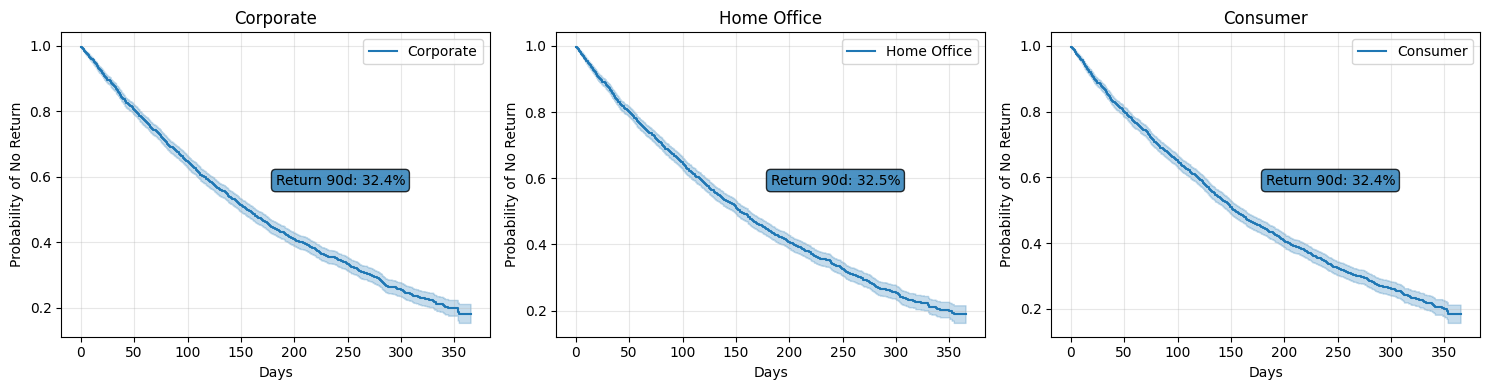

In [66]:
def prepare_survival_data(df):
    """Prepare data for survival analysis"""
    # First purchase
    first = df.groupby('Customer_ID')['Order_Date'].min().reset_index()
    first.columns = ['Customer_ID', 'First_Date']
    
    # Second purchase
    df_sorted = df.sort_values(['Customer_ID', 'Order_Date'])
    df_sorted['Order_Num'] = df_sorted.groupby('Customer_ID').cumcount() + 1
    second = df_sorted[df_sorted['Order_Num'] == 2][['Customer_ID', 'Order_Date']]
    second.columns = ['Customer_ID', 'Second_Date']
    
    # Combine
    survival = first.merge(second, on='Customer_ID', how='left')
    survival['Returned'] = survival['Second_Date'].notna().astype(int)
    
    # Time to event or censoring
    end_date = df['Order_Date'].max()
    survival['Time_to_Event'] = survival.apply(
        lambda x: (x['Second_Date'] - x['First_Date']).days if x['Returned'] 
        else (end_date - x['First_Date']).days, axis=1
    )
    
    # Add segment
    segments = df[['Customer_ID', 'Customer_Segment']].drop_duplicates()
    survival = survival.merge(segments, on='Customer_ID')
    
    return survival

survival_data = prepare_survival_data(df)

# Plot survival curves by segment
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, segment in enumerate(df['Customer_Segment'].unique()):
    seg_data = survival_data[survival_data['Customer_Segment'] == segment]
    kmf = KaplanMeierFitter()
    kmf.fit(seg_data['Time_to_Event'], seg_data['Returned'], label=segment)
    
    kmf.plot_survival_function(ax=axes[i])
    axes[i].set_title(f'{segment}')
    axes[i].set_xlabel('Days')
    axes[i].set_ylabel('Probability of No Return')
    axes[i].grid(True, alpha=0.3)
    
    return_90d = 1 - kmf.predict(90)
    axes[i].text(0.5, 0.5, f'Return 90d: {return_90d:.1%}', 
                transform=axes[i].transAxes, bbox=dict(boxstyle="round", alpha=0.8))

plt.tight_layout()
plt.show()

##### Here we also see the results of the survival analysis. According to this analysis, there is no difference between segments in the probability of returning after 90 days, and we observe that the Probability of No Return graphs behave similarly across segments.

## Category & Payment Preferences
### What they buy and how they pay

In [67]:
# Category preferences
category_pref = pd.crosstab(df['Customer_Segment'], df['Product_Category'], normalize='index') * 100
print("=== CATEGORY PREFERENCES (%) ===")
print(category_pref.round(1))

# Payment preferences
payment_pref = pd.crosstab(df['Customer_Segment'], df['Payment_Method'], normalize='index') * 100
print("\n=== PAYMENT PREFERENCES (%) ===")
print(payment_pref.round(1))

=== CATEGORY PREFERENCES (%) ===
Product_Category  Beauty  Clothing  Electronics  Home & Kitchen  Sports
Customer_Segment                                                       
Consumer            20.5      19.7         19.0            19.8    21.0
Corporate           19.3      20.2         20.4            20.6    19.5
Home Office         20.1      20.3         20.3            19.9    19.4

=== PAYMENT PREFERENCES (%) ===
Payment_Method    Cash on Delivery  Credit Card  Debit Card  Net Banking   UPI
Customer_Segment                                                              
Consumer                      19.8         20.2        20.1         19.2  20.8
Corporate                     20.4         19.6        20.7         19.1  20.2
Home Office                   20.3         19.2        21.5         19.7  19.4


##### I checked whether there are differences in category preferences or payment preferences by segment. No differences are observed.

## Segment Profiles
### Key characteristics of each segment

In [68]:
segment_profiles = {}
for segment in df['Customer_Segment'].unique():
    seg_customers = customer_orders[customer_orders['Segment'] == segment]
    seg_survival = survival_data[survival_data['Customer_Segment'] == segment]
    
    kmf = KaplanMeierFitter()
    kmf.fit(seg_survival['Time_to_Event'], seg_survival['Returned'])
    
    segment_profiles[segment] = {
        'Repeat_Rate': (seg_customers['Order_Count'] > 1).mean() * 100,
        'Multi_Buyer_Rate': (seg_customers['Order_Count'] > 2).mean() * 100,
        'Avg_Orders': seg_customers['Order_Count'].mean(),
        'Return_90d': 1 - kmf.predict(90),
        'Return_180d': 1 - kmf.predict(180),
        'Top_Category': df[df['Customer_Segment'] == segment]['Product_Category'].mode()[0],
        'Top_Payment': df[df['Customer_Segment'] == segment]['Payment_Method'].mode()[0]
    }

print("=== SEGMENT PROFILES ===")
for segment, profile in segment_profiles.items():
    print(f"\n📌 {segment.upper()}")
    print(f"  • Repeat rate: {profile['Repeat_Rate']:.1f}%")
    print(f"  • Multi-buyer rate: {profile['Multi_Buyer_Rate']:.1f}%")
    print(f"  • Return within 90 days: {profile['Return_90d']:.1%}")
    print(f"  • Top category: {profile['Top_Category']}")
    print(f"  • Top payment: {profile['Top_Payment']}")

=== SEGMENT PROFILES ===

📌 CORPORATE
  • Repeat rate: 46.1%
  • Multi-buyer rate: 15.5%
  • Return within 90 days: 32.4%
  • Top category: Home & Kitchen
  • Top payment: Debit Card

📌 HOME OFFICE
  • Repeat rate: 47.1%
  • Multi-buyer rate: 17.1%
  • Return within 90 days: 32.5%
  • Top category: Clothing
  • Top payment: Debit Card

📌 CONSUMER
  • Repeat rate: 44.2%
  • Multi-buyer rate: 14.8%
  • Return within 90 days: 32.4%
  • Top category: Sports
  • Top payment: UPI


##### I extracted the segments' repeat order probabilities, multi-buyer rates, probability of reordering within 90 days, top categories (where we previously observed no differences), and top payment preferences (where we also previously observed no differences).

## Loyalty Program Recommendations by Segment
### Tailored strategies for each customer type

In [69]:
print("\n" + "="*70)
print("LOYALTY PROGRAM RECOMMENDATIONS BY SEGMENT")
print("="*70)

for segment, profile in segment_profiles.items():
    print(f"\n🔹 {segment.upper()}")
    print("-" * 40)
    
    if segment == "Corporate":
        print("📊 PROFILE: High-value B2B buyers")
        print(f"   • {profile['Repeat_Rate']:.1f}% repeat rate")
        print(f"   • Returns within {survival_data[survival_data['Customer_Segment']==segment]['Time_to_Event'].median():.0f} days")
        
        print("\n✅ RECOMMENDED PROGRAM:")
        print("   • Tiered Volume Discounts based on annual spend")
        print("   • Account-Based Rewards (company-level, not individual)")
        print("   • Procurement integration with Net Banking")
        print(f"   • Category focus: {profile['Top_Category']} and Electronics")
        
        print("\n🎯 LOYALTY MECHANICS:")
        print("   • Bronze (<$5K): 2% rebate")
        print("   • Silver ($5K-$20K): 5% rebate + free expedited shipping")
        print("   • Gold (>$20K): 8% rebate + dedicated account manager")
        
    elif segment == "Consumer":
        print("📊 PROFILE: Individual retail buyers")
        print(f"   • {profile['Repeat_Rate']:.1f}% repeat rate")
        print(f"   • {profile['Multi_Buyer_Rate']:.1f}% buy 3+ times")
        print(f"   • Returns within 90 days: {profile['Return_90d']:.1%}")
        
        print("\n✅ RECOMMENDED PROGRAM:")
        print("   • Points-Based System (1 point per $ spent)")
        print("   • Tiered benefits based on annual spend")
        print(f"   • Category bonuses on {profile['Top_Category']}")
        print("   • Digital-first with UPI/Debit Card integration")
        
        print("\n🎯 LOYALTY MECHANICS:")
        print("   • 500 points = $5 off")
        print("   • Birthday bonus: 100 points")
        print("   • First purchase of month: Double points")
        print("   • Refer a friend: 200 points")
        
    elif segment == "Home Office":
        print("📊 PROFILE: Small business/remote workers")
        print(f"   • {profile['Repeat_Rate']:.1f}% repeat rate")
        print(f"   • Returns within {survival_data[survival_data['Customer_Segment']==segment]['Time_to_Event'].median():.0f} days")
        
        print("\n✅ RECOMMENDED PROGRAM:")
        print("   • Hybrid Program (consumer + business benefits)")
        print("   • Enhanced rewards on office categories")
        print("   • Flexible rewards (personal or business use)")
        
        print("\n🎯 LOYALTY MECHANICS:")
        print("   • Business expense tracking for tax purposes")
        print("   • Quarterly spending bonuses")
        print("   • Category focus: Home & Kitchen, Electronics")


LOYALTY PROGRAM RECOMMENDATIONS BY SEGMENT

🔹 CORPORATE
----------------------------------------
📊 PROFILE: High-value B2B buyers
   • 46.1% repeat rate
   • Returns within 118 days

✅ RECOMMENDED PROGRAM:
   • Tiered Volume Discounts based on annual spend
   • Account-Based Rewards (company-level, not individual)
   • Procurement integration with Net Banking
   • Category focus: Home & Kitchen and Electronics

🎯 LOYALTY MECHANICS:
   • Bronze (<$5K): 2% rebate
   • Silver ($5K-$20K): 5% rebate + free expedited shipping
   • Gold (>$20K): 8% rebate + dedicated account manager

🔹 HOME OFFICE
----------------------------------------
📊 PROFILE: Small business/remote workers
   • 47.1% repeat rate
   • Returns within 117 days

✅ RECOMMENDED PROGRAM:
   • Hybrid Program (consumer + business benefits)
   • Enhanced rewards on office categories
   • Flexible rewards (personal or business use)

🎯 LOYALTY MECHANICS:
   • Business expense tracking for tax purposes
   • Quarterly spending bonuse

## Implementation Roadmap
### Phased approach based on opportunity

In [70]:
print("\n" + "="*70)
print("IMPLEMENTATION PRIORITY")
print("="*70)

segment_priority = segment_value.copy()
segment_priority['Revenue_Share'] = segment_priority['Total_Revenue'] / segment_priority['Total_Revenue'].sum() * 100
segment_priority['Opportunity'] = segment_priority.apply(
    lambda x: x['Revenue_Share'] * (1 - repeat_stats.loc[x.name, 'Repeat_Rate']/100), axis=1
)

print("\n📊 SEGMENT OPPORTUNITY:")
for segment in segment_priority.index:
    share = segment_priority.loc[segment, 'Revenue_Share']
    repeat = repeat_stats.loc[segment, 'Repeat_Rate']
    opportunity = segment_priority.loc[segment, 'Opportunity']
    
    print(f"\n{segment}:")
    print(f"  • {share:.1f}% of total revenue")
    print(f"  • {repeat:.1f}% repeat rate")
    print(f"  • Opportunity to convert {100-repeat:.1f}% one-time buyers")
    print(f"  • Priority score: {opportunity:.1f}")

print("\n✅ RECOMMENDED PHASING:")
print("Phase 1 (Months 1-2): Pilot with Consumer segment (largest opportunity)")
print("Phase 2 (Months 3-4): Roll out to Corporate with B2B modifications")
print("Phase 3 (Months 5-6): Adapt for Home Office segment")
print("Phase 4: Measure, learn, and iterate")

print("\n📈 SUCCESS METRICS:")
print("• Repeat rate increase (target: +5-10% in year 1)")
print("• Average order value among loyalty members")
print("• Redemption rate (target: >30%)")
print("• Segment-specific: Corporate contract renewals, Consumer app engagement")


IMPLEMENTATION PRIORITY

📊 SEGMENT OPPORTUNITY:

Consumer:
  • 33.3% of total revenue
  • 44.2% repeat rate
  • Opportunity to convert 55.8% one-time buyers
  • Priority score: 18.6

Corporate:
  • 33.4% of total revenue
  • 46.1% repeat rate
  • Opportunity to convert 53.9% one-time buyers
  • Priority score: 18.0

Home Office:
  • 33.3% of total revenue
  • 47.1% repeat rate
  • Opportunity to convert 52.9% one-time buyers
  • Priority score: 17.6

✅ RECOMMENDED PHASING:
Phase 1 (Months 1-2): Pilot with Consumer segment (largest opportunity)
Phase 2 (Months 3-4): Roll out to Corporate with B2B modifications
Phase 3 (Months 5-6): Adapt for Home Office segment
Phase 4: Measure, learn, and iterate

📈 SUCCESS METRICS:
• Repeat rate increase (target: +5-10% in year 1)
• Average order value among loyalty members
• Redemption rate (target: >30%)
• Segment-specific: Corporate contract renewals, Consumer app engagement


## Key Takeaways
### Summary for Marketing Team

In [71]:
print("\n" + "="*70)
print("KEY TAKEAWAYS")
print("="*70)

one_time_rate = (customer_orders['Order_Count'] == 1).mean() * 100
print(f"\n📊 Overall one-time buyer rate: {one_time_rate:.1f}%")

print("\n The Opportunity:")
print(f"• Corporate: {segment_profiles['Corporate']['Repeat_Rate']:.1f}% repeat rate → B2B volume program")
print(f"• Consumer: {segment_profiles['Consumer']['Repeat_Rate']:.1f}% repeat rate → points-based program") 
print(f"• Home Office: {segment_profiles['Home Office']['Repeat_Rate']:.1f}% repeat rate → hybrid program")

print("\n Critical Window:")
print("• 50% of returns happen within first 60-90 days")
print("• Focus re-engagement campaigns in this window")

print("\n Financial Impact Potential:")
print("• Increasing repeat rate by 5% across segments")
print(f"• Could generate ${df['Revenue'].sum() * 0.05:,.0f} in additional revenue")


KEY TAKEAWAYS

📊 Overall one-time buyer rate: 54.2%

 The Opportunity:
• Corporate: 46.1% repeat rate → B2B volume program
• Consumer: 44.2% repeat rate → points-based program
• Home Office: 47.1% repeat rate → hybrid program

 Critical Window:
• 50% of returns happen within first 60-90 days
• Focus re-engagement campaigns in this window

 Financial Impact Potential:
• Increasing repeat rate by 5% across segments
• Could generate $597,621 in additional revenue


### Future Data & Feature Enhancements (Marketing)

To strengthen the loyalty and CLV analysis, the following additional data and features would be especially valuable:

- **Richer product & channel data**: Product IDs/brands, sub-categories, price tiers, acquisition channel and campaign IDs to understand which products and campaigns drive truly loyal, profitable customers.
- **Customer behavior over time**: More detailed recency/frequency metrics, seasonality flags (e.g., holidays, peak seasons), and channel usage patterns to refine CLV estimates and retention targeting.
- **Discount response features**: Per-customer measures of discount reliance (share of discounted orders, spend without discounts) to distinguish loyal customers from promo-only shoppers.
- **Cross-category engagement**: Features capturing category and brand breadth (how many different categories a customer buys from) as a signal of deeper engagement and higher long‑term value.
- **Demographic and geographic attributes** (where appropriate): Age bands, city/region granularity, and delivery cost proxies to design loyalty tiers that are both profitable and fair across segments.